In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120 # Resolusi tinggi

df_summary = pd.read_csv('summary_simulation_results.csv')
df_items = pd.read_csv('item_level_logs.csv')

best_scenario_id = df_summary.iloc[0]['Skenario']
print(f"Skenario Terbaik yang akan dianalisis: {best_scenario_id}")

df_scenario = pd.read_excel('scenario_level_logs.xlsx', sheet_name=best_scenario_id[:31])

df_best_items = df_items[df_items['scenario_id'] == best_scenario_id].copy()

df_merged_items = pd.merge(
    df_best_items, 
    df_scenario[['student_id', 'ability_category', 'true_ability']], 
    on='student_id', 
    how='left'
)

Skenario Terbaik yang akan dianalisis: SL3-TL2-ST3


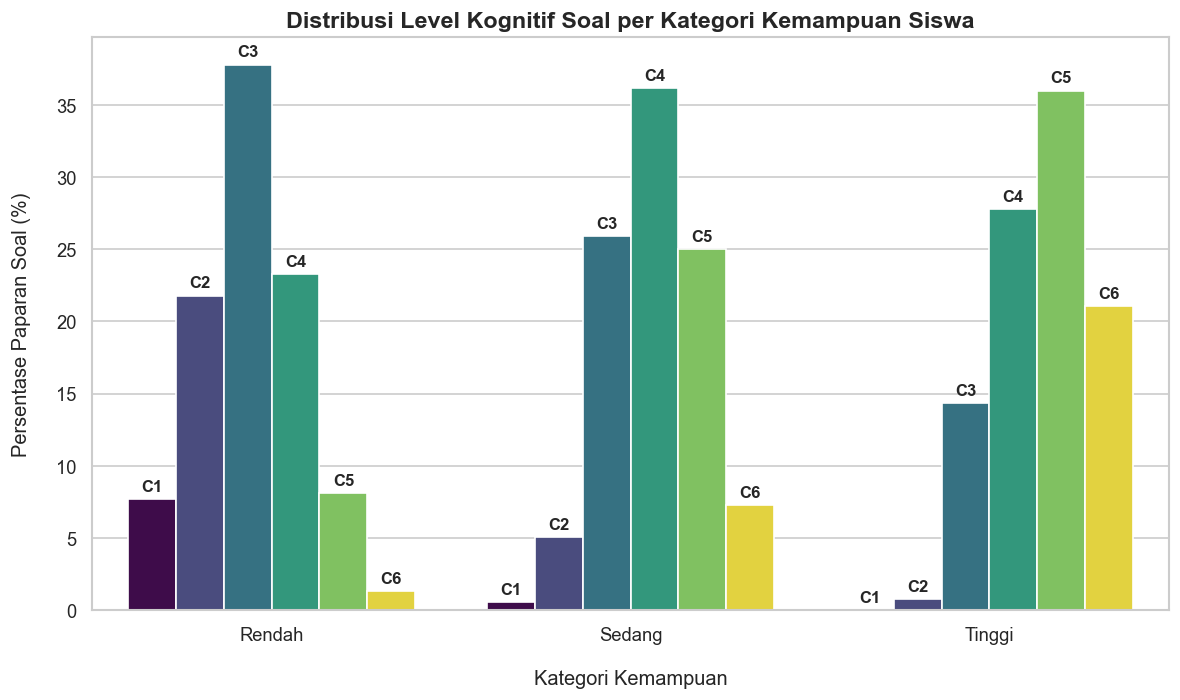

In [2]:
cog_distribution = df_merged_items.groupby(['ability_category', 'cognitive_level']).size().reset_index(name='jumlah_soal')
total_per_category = df_merged_items.groupby('ability_category').size().reset_index(name='total')
cog_distribution = pd.merge(cog_distribution, total_per_category, on='ability_category')
cog_distribution['persentase'] = (cog_distribution['jumlah_soal'] / cog_distribution['total']) * 100

plt.figure(figsize=(10, 6))
order_cat = ['Rendah', 'Sedang', 'Tinggi']

ax = sns.barplot(
    data=cog_distribution, 
    x='ability_category', 
    y='persentase', 
    hue='cognitive_level', 
    order=order_cat,
    palette='viridis'
)

plt.title('Distribusi Level Kognitif Soal per Kategori Kemampuan Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kemampuan', fontsize=12, labelpad=15)
plt.ylabel('Persentase Paparan Soal (%)', fontsize=12, labelpad=15)

ax.get_legend().remove()

level_labels = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']

for i, container in enumerate(ax.containers):
    ax.bar_label(container, labels=[level_labels[i]] * len(container), padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [20]:
order_cat = ['Rendah', 'Sedang', 'Tinggi']

for cat in order_cat:
    data_kategori = cog_distribution[cog_distribution['ability_category'] == cat]
    total_soal_kategori = data_kategori['total'].iloc[0] if not data_kategori.empty else 0
    
    print(f"\nKategori Kemampuan {cat} ({total_soal_kategori} Soal)")
    print("-" * 50)
    
    data_kategori = data_kategori.sort_values(by='cognitive_level')
    
    for index, row in data_kategori.iterrows():
        level = int(row['cognitive_level'])
        jumlah = int(row['jumlah_soal'])
        persen = row['persentase']

        print(f"   • Level C{level}: {jumlah} soal ({persen:.1f}%)")



Kategori Kemampuan Rendah (9746 Soal)
--------------------------------------------------
   • Level C1: 748 soal (7.7%)
   • Level C2: 2124 soal (21.8%)
   • Level C3: 3683 soal (37.8%)
   • Level C4: 2271 soal (23.3%)
   • Level C5: 790 soal (8.1%)
   • Level C6: 130 soal (1.3%)

Kategori Kemampuan Sedang (12481 Soal)
--------------------------------------------------
   • Level C1: 70 soal (0.6%)
   • Level C2: 633 soal (5.1%)
   • Level C3: 3234 soal (25.9%)
   • Level C4: 4513 soal (36.2%)
   • Level C5: 3125 soal (25.0%)
   • Level C6: 906 soal (7.3%)

Kategori Kemampuan Tinggi (7512 Soal)
--------------------------------------------------
   • Level C1: 2 soal (0.0%)
   • Level C2: 56 soal (0.7%)
   • Level C3: 1079 soal (14.4%)
   • Level C4: 2089 soal (27.8%)
   • Level C5: 2704 soal (36.0%)
   • Level C6: 1582 soal (21.1%)


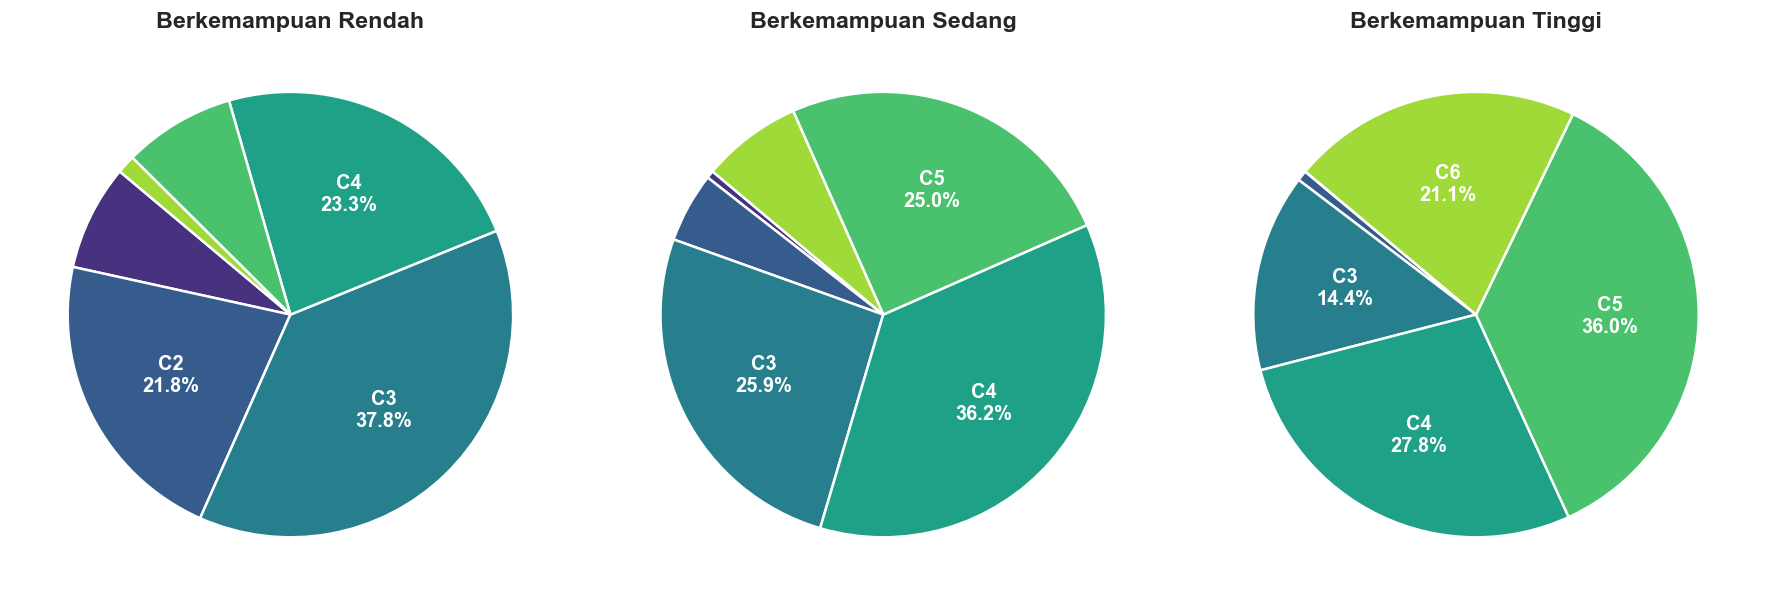

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# fig.suptitle('Distribusi Level Kognitif Soal per Kategori Kemampuan Siswa', 
            # fontsize=16, fontweight='bold', y=1.05)

order_cat = ['Rendah', 'Sedang', 'Tinggi']
base_colors = sns.color_palette('viridis', 6)

for i, cat in enumerate(order_cat):
    data_cat = cog_distribution[cog_distribution['ability_category'] == cat].sort_values('cognitive_level')
    
    pie_colors = [base_colors[int(lvl)-1] for lvl in data_cat['cognitive_level']]
    
    wedges, texts, autotexts = axes[i].pie(
        data_cat['persentase'], 
        autopct='%1.1f%%',  
        startangle=140,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'} 
    )
    
    for j, autotext in enumerate(autotexts):
        pct_val = data_cat['persentase'].iloc[j]
        
        if pct_val > 10:
            lvl = int(data_cat['cognitive_level'].iloc[j])
            autotext.set_text(f"C{lvl}\n{pct_val:.1f}%")
        else:
            autotext.set_text('')
    
    axes[i].set_title(f'Berkemampuan {cat}', fontsize=14, fontweight='bold', pad=5)

plt.tight_layout()
plt.show()

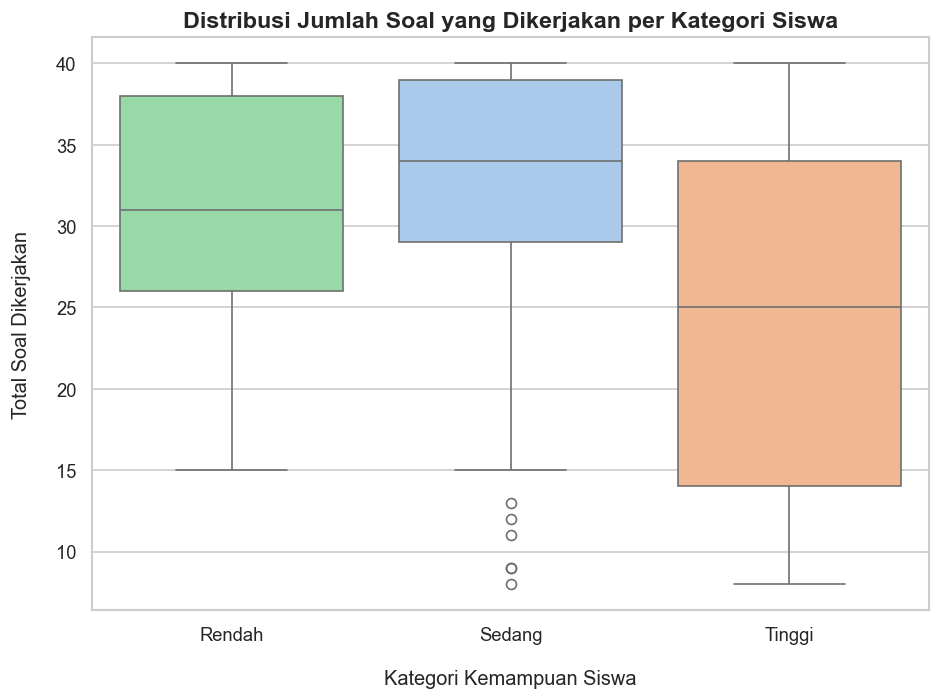

In [4]:
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_scenario, 
    x='ability_category', 
    y='total_items', 
    order=order_cat, 
    hue='ability_category', 
    palette='pastel', 
    legend=False            
)

plt.title('Distribusi Jumlah Soal yang Dikerjakan per Kategori Siswa', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kemampuan Siswa', fontsize=12, labelpad=15)
plt.ylabel('Total Soal Dikerjakan', fontsize=12, labelpad=15)
plt.tight_layout()
plt.show()

In [22]:
order_cat = ['Rendah', 'Sedang', 'Tinggi']

for cat in order_cat:
    data_kategori = df_scenario[df_scenario['ability_category'] == cat]['total_items']
    
    count = data_kategori.count()
    mean_val = data_kategori.mean()
    min_val = data_kategori.min()
    q1 = data_kategori.quantile(0.25)      
    median_val = data_kategori.median()    
    q3 = data_kategori.quantile(0.75)      
    max_val = data_kategori.max()
    
    print(f"\nKategori Kemampuan {cat} ({count} Soal)")
    print(f"   • Rata-rata (Mean)      : {mean_val:.1f} soal")
    print(f"   • Nilai Minimum         : {min_val:.0f} soal")
    print(f"   • Kuartil Bawah (Q1)    : {q1:.0f} soal")
    print(f"   • Nilai Tengah (Median) : {median_val:.0f} soal")
    print(f"   • Kuartil Atas (Q3)     : {q3:.0f} soal")
    print(f"   • Nilai Maksimum        : {max_val:.0f} soal")



Kategori Kemampuan Rendah (313 Soal)
   • Rata-rata (Mean)      : 31.1 soal
   • Nilai Minimum         : 15 soal
   • Kuartil Bawah (Q1)    : 26 soal
   • Nilai Tengah (Median) : 31 soal
   • Kuartil Atas (Q3)     : 38 soal
   • Nilai Maksimum        : 40 soal

Kategori Kemampuan Sedang (381 Soal)
   • Rata-rata (Mean)      : 32.8 soal
   • Nilai Minimum         : 8 soal
   • Kuartil Bawah (Q1)    : 29 soal
   • Nilai Tengah (Median) : 34 soal
   • Kuartil Atas (Q3)     : 39 soal
   • Nilai Maksimum        : 40 soal

Kategori Kemampuan Tinggi (306 Soal)
   • Rata-rata (Mean)      : 24.5 soal
   • Nilai Minimum         : 8 soal
   • Kuartil Bawah (Q1)    : 14 soal
   • Nilai Tengah (Median) : 25 soal
   • Kuartil Atas (Q3)     : 34 soal
   • Nilai Maksimum        : 40 soal


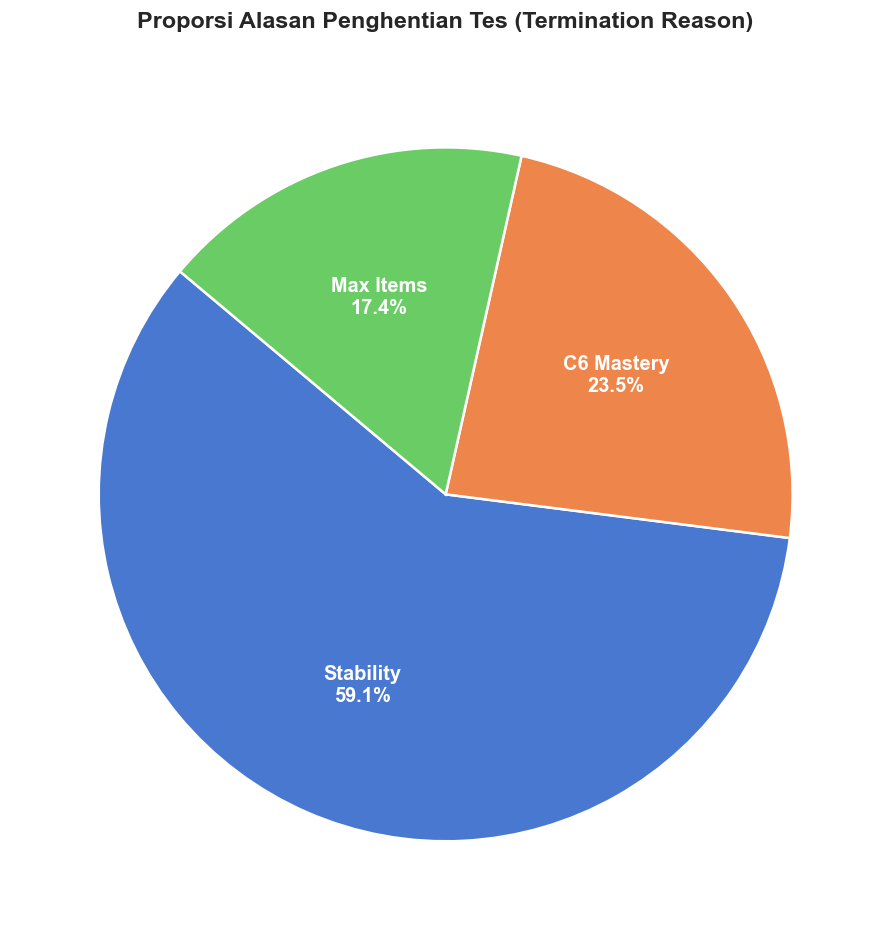

In [5]:
term_reason = df_scenario['termination_reason'].value_counts()
total_reasons = term_reason.sum()

palette = sns.color_palette("muted") 

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    term_reason, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=palette,  
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'} 
)

for i, autotext in enumerate(autotexts):
    count = term_reason.iloc[i]
    pct_val = (count / total_reasons) * 100

    if pct_val > 8:
        reason = term_reason.index[i]
        autotext.set_text(f"{reason}\n{pct_val:.1f}%")
    else:
        autotext.set_text('')

plt.title('Proporsi Alasan Penghentian Tes (Termination Reason)', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

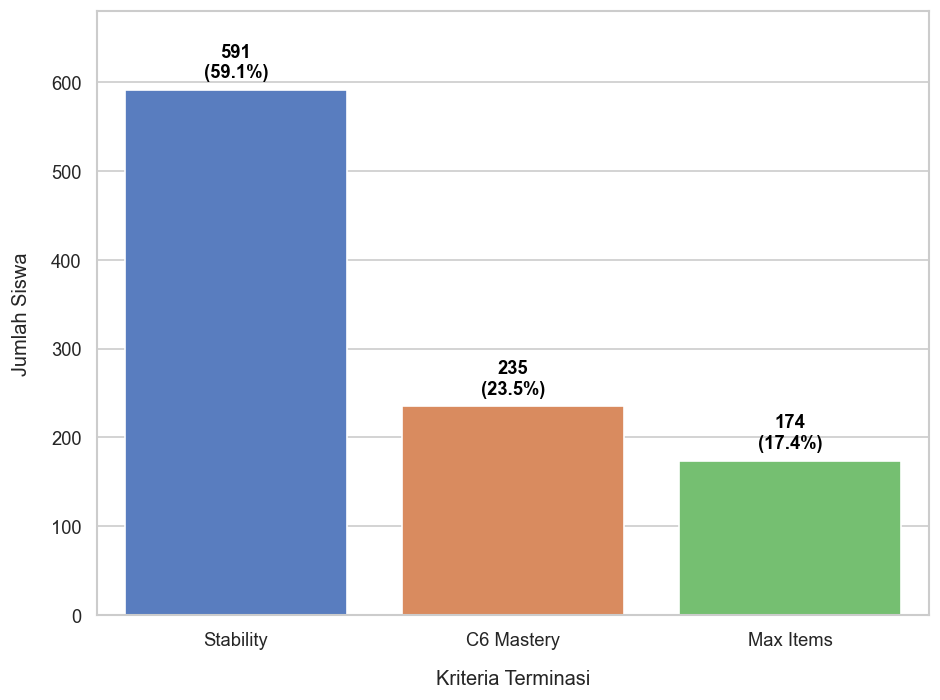

In [32]:
term_counts = df_scenario['termination_reason'].value_counts().reset_index()
term_counts.columns = ['reason', 'count']
total_students = term_counts['count'].sum()

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=term_counts, 
    x='reason', 
    y='count', 
    hue='reason',
    palette='muted', 
    legend=False
)

# plt.title('Alasan Penghentian Tes (Termination Reason)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Kriteria Terminasi', fontsize=12, labelpad=12)
plt.ylabel('Jumlah Siswa', fontsize=12, labelpad=12)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        if height > 0: 
            pct = (height / total_students) * 100
            labels.append(f"{int(height)}\n({pct:.1f}%)")
        else:
            labels.append("")

    ax.bar_label(container, labels=labels, padding=5, fontsize=11, fontweight='bold', color='black')

plt.ylim(0, term_counts['count'].max() * 1.15)

plt.tight_layout()
plt.show()

In [24]:
term_reason = df_scenario['termination_reason'].value_counts()
total_reasons = term_reason.sum()

print(f"Total Keseluruhan Siswa : {total_reasons} siswa")
print("-" * 55)

for reason, count in term_reason.items():
    pct_val = (count / total_reasons) * 100
    
    print(f"   • {reason:<15}: {count} siswa ({pct_val:.1f}%)")


Total Keseluruhan Siswa : 1000 siswa
-------------------------------------------------------
   • Stability      : 591 siswa (59.1%)
   • C6 Mastery     : 235 siswa (23.5%)
   • Max Items      : 174 siswa (17.4%)


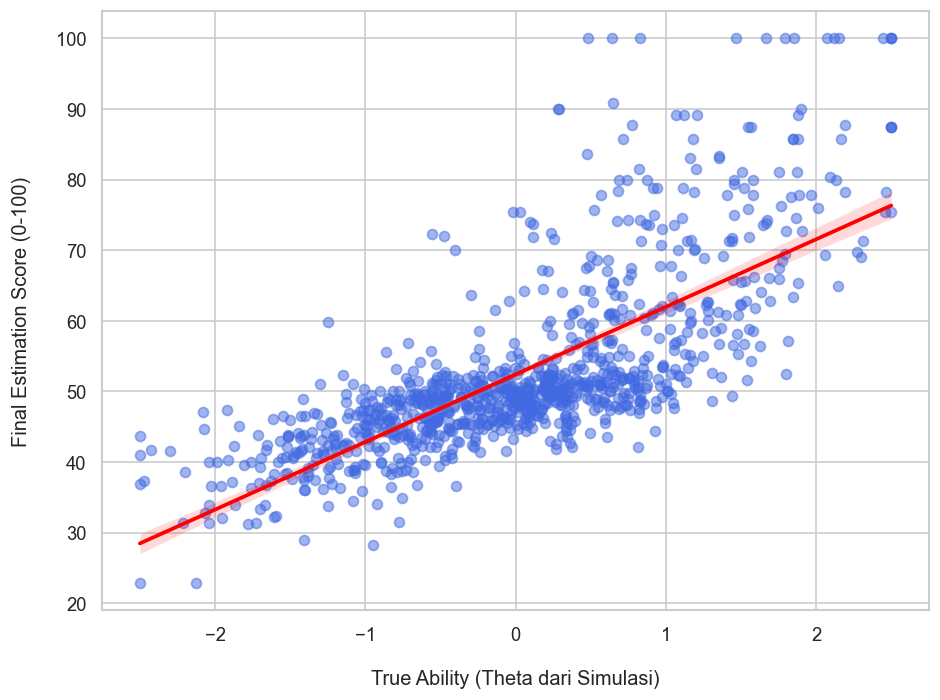

In [26]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df_scenario, x='true_ability', y='final_estimation_score', 
            scatter_kws={'alpha':0.5, 'color':'royalblue'}, line_kws={'color':'red'})
# plt.title('Korelasi Kemampuan Asli (Theta) vs Skor Estimasi Akhir CAT', fontsize=14, fontweight='bold')
plt.xlabel('True Ability (Theta dari Simulasi)', fontsize=12, labelpad=15)
plt.ylabel('Final Estimation Score (0-100)', fontsize=12, labelpad=15)
plt.tight_layout()
plt.show()


In [ ]:
pearson_val = df_summary.iloc[0]['Pearson']
spearman_val = df_summary.iloc[0]['Spearman']
mean_bias = df_summary.iloc[0]['Bias']

print("Perfomance")
print(f"   • Korelasi Pearson  : {pearson_val:.3f}")
print(f"   • Korelasi Spearman : {spearman_val:.3f}")
print(f"   • Rata-rata Bias    : {mean_bias:.2f} poin")
print("-" * 65)


print("Rata-rata Skor Berdasarkan Rentang Kemampuan")
bins = [-3.0, -1.5, -0.5, 0.5, 1.5, 3.0]
labels = [
    'Sangat Rendah (< -1.5)', 
    'Rendah (-1.5 s.d -0.5)', 
    'Sedang (-0.5 s.d 0.5)', 
    'Tinggi (0.5 s.d 1.5)', 
    'Sangat Tinggi (> 1.5)'
]

df_scenario_copy = df_scenario.copy()
df_scenario_copy['theta_group'] = pd.cut(df_scenario_copy['true_ability'], bins=bins, labels=labels)

grouped_stats = df_scenario_copy.groupby('theta_group', observed=False)['final_estimation_score'].agg(['count', 'mean']).dropna()

for index, row in grouped_stats.iterrows():
    count = int(row['count'])
    mean_score = row['mean']
    print(f"   • {index:<25} : Rata-rata Skor {mean_score:.1f} ({count} siswa)")

Perfomance
   • Korelasi Pearson  : 0.741
   • Korelasi Spearman : 0.784 (Akurasi Peringkat Siswa)
   • Rata-rata Bias    : 2.20 poin
-----------------------------------------------------------------
Rata-rata Skor Berdasarkan Rentang Kemampuan
   • Sangat Rendah (< -1.5)    : Rata-rata Skor 38.6 (57 siswa)
   • Rendah (-1.5 s.d -0.5)    : Rata-rata Skor 44.7 (256 siswa)
   • Sedang (-0.5 s.d 0.5)     : Rata-rata Skor 50.7 (381 siswa)
   • Tinggi (0.5 s.d 1.5)      : Rata-rata Skor 60.0 (231 siswa)
   • Sangat Tinggi (> 1.5)     : Rata-rata Skor 76.5 (75 siswa)


In [8]:
pearson_val = df_summary.iloc[0]['Pearson']
spearman_val = df_summary.iloc[0]['Spearman']
print(f"Nilai Correlation adalah {spearman_val:.3f}. Semakin mendekati 1, semakin akurat tes mengukur siswa.")


Nilai Correlation adalah 0.784. Semakin mendekati 1, semakin akurat tes mengukur siswa.


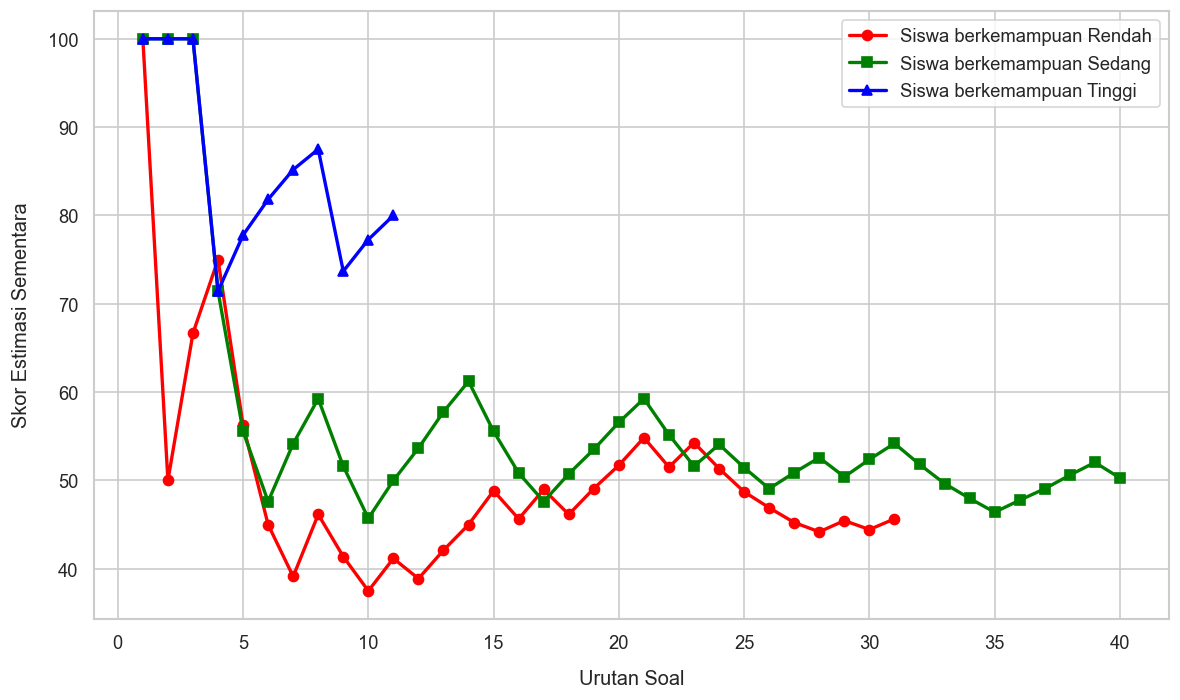

In [31]:
np.random.seed(42)
sample_students = df_scenario.groupby('ability_category').sample(n=1, random_state=42).reset_index(drop=True)

plt.figure(figsize=(10, 6))
markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']

for idx, row in sample_students.iterrows():
    student_id = row['student_id']
    cat = row['ability_category']
    
    hist_student = df_best_items[df_best_items['student_id'] == student_id].copy()
    hist_student['item_order'] = range(1, len(hist_student) + 1)
    
    plt.plot(hist_student['item_order'], hist_student['estimation_score_after_item'], 
             marker=markers[idx], color=colors[idx], linewidth=2, 
             label=f'Siswa berkemampuan {cat}')

# plt.title('Perjalanan Skor Siswa (Trajectory) selama Tes Berlangsung', fontsize=14, fontweight='bold')
plt.xlabel('Urutan Soal', fontsize=12, labelpad=10)
plt.ylabel('Skor Estimasi Sementara', fontsize=12, labelpad=10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
for idx, row in sample_students.iterrows():
    student_id = row['student_id']
    cat = row['ability_category']
    reason = row['termination_reason']
    
    print(f"Trajektori {student_id} | True Ability {cat}")
    print(f"Termination Rule {reason}")
    
    hist_student = df_best_items[df_best_items['student_id'] == student_id].copy()
    hist_student['item_order'] = range(1, len(hist_student) + 1)
    
    hist_student['rolling_max'] = hist_student['estimation_score_after_item'].rolling(window=5, min_periods=5).max()
    hist_student['rolling_min'] = hist_student['estimation_score_after_item'].rolling(window=5, min_periods=5).min()
    hist_student['stability_range'] = hist_student['rolling_max'] - hist_student['rolling_min']
    
    log_display = hist_student[[
        'item_order', 'cognitive_level', 'response', 
        'estimation_score_after_item', 'stability_range'
    ]].copy()
    
    log_display['response'] = log_display['response'].apply(lambda x: '1' if x == 1 else '0')
    log_display['estimation_score_after_item'] = log_display['estimation_score_after_item'].round(2)
    log_display['stability_range'] = log_display['stability_range'].round(2)
    log_display['stability_range'] = log_display['stability_range'].fillna('-')
    
    log_display.rename(columns={
        'item_order': 'Soal Ke-',
        'cognitive_level': 'Level Kognitif',
        'response': 'Jawaban',
        'estimation_score_after_item': 'Skor Sementara',
        'stability_range': 'Treshold'
    }, inplace=True)
    
    print(log_display.to_string(index=False))
    print("\n\n")

Trajektori S0147 | True Ability Rendah
Termination Rule Stability
 Soal Ke-  Level Kognitif Jawaban  Skor Sementara Treshold
        1               3       1          100.00        -
        2               3       0           50.00        -
        3               3       1           66.67        -
        4               3       1           75.00        -
        5               4       0           56.25     50.0
        6               4       0           45.00     30.0
        7               3       0           39.13    35.87
        8               3       1           46.15    35.87
        9               3       0           41.38    17.12
       10               3       0           37.50     8.65
       11               2       1           41.18     8.65
       12               2       0           38.89     8.65
       13               2       1           42.11     4.61
       14               2       1           45.00      7.5
       15               3       1           48.84

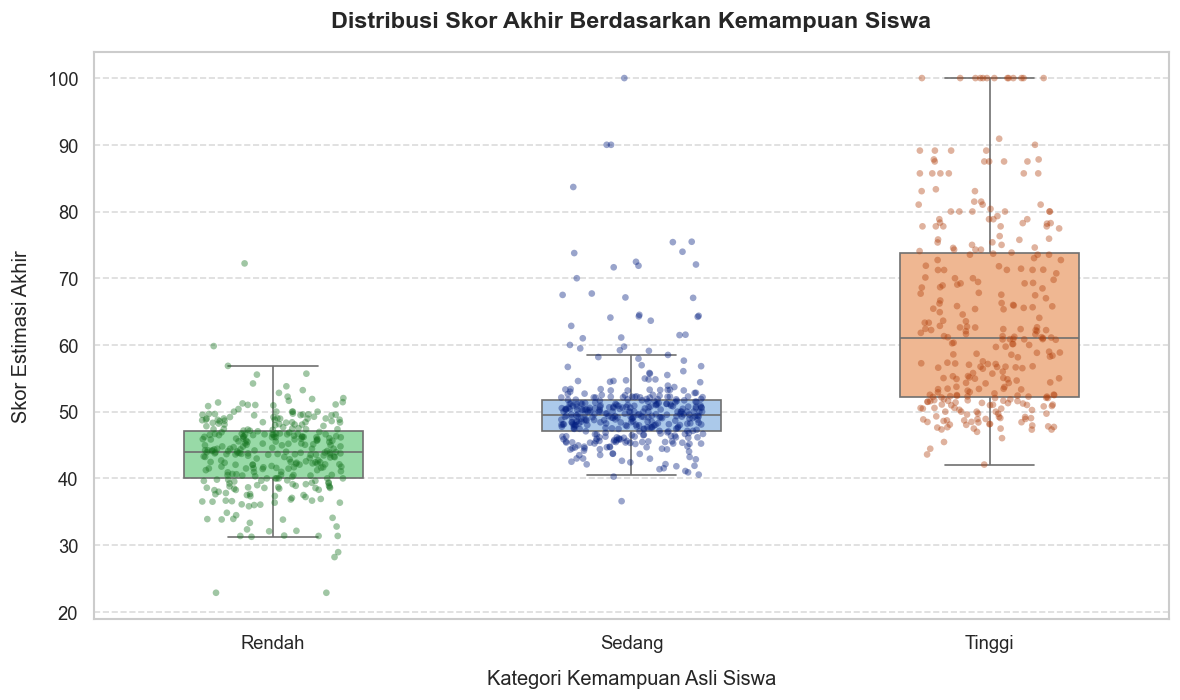

In [10]:
plt.figure(figsize=(10, 6))

order_cat = ['Rendah', 'Sedang', 'Tinggi']

sns.boxplot(
    data=df_scenario, 
    x='ability_category', 
    y='final_estimation_score', 
    order=order_cat,
    hue='ability_category',  
    palette='pastel',       
    legend=False,
    width=0.5,
    showfliers=False         
)

sns.stripplot(
    data=df_scenario, 
    x='ability_category', 
    y='final_estimation_score', 
    order=order_cat,
    hue='ability_category', 
    palette='dark',         
    legend=False,
    alpha=0.4,             
    jitter=0.2,            
    size=4
)

plt.title(f'Distribusi Skor Akhir Berdasarkan Kemampuan Siswa', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kategori Kemampuan Asli Siswa', fontsize=12, labelpad=10)
plt.ylabel('Skor Estimasi Akhir', fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [29]:
order_cat = ['Rendah', 'Sedang', 'Tinggi']

for cat in order_cat:
    data_kategori = df_scenario[df_scenario['ability_category'] == cat]['final_estimation_score']
    count = data_kategori.count()
    mean_val = data_kategori.mean()
    std_val = data_kategori.std()          
    min_val = data_kategori.min()
    q1 = data_kategori.quantile(0.25)
    median_val = data_kategori.median()
    q3 = data_kategori.quantile(0.75)
    max_val = data_kategori.max()
    
    print(f"\nKategori Kemampuan {cat} ({count} Siswa)")
    print("-" * 60)
    print(f"   • Rata-rata Skor (Mean)   : {mean_val:.2f} ± {std_val:.2f}")
    print(f"   • Skor Minimum            : {min_val:.2f}")
    print(f"   • Kuartil Bawah (Q1)      : {q1:.2f}")
    print(f"   • Nilai Tengah (Median)   : {median_val:.2f}")
    print(f"   • Kuartil Atas (Q3)       : {q3:.2f}")
    print(f"   • Skor Maksimum           : {max_val:.2f}")



Kategori Kemampuan Rendah (313 Siswa)
------------------------------------------------------------
   • Rata-rata Skor (Mean)   : 43.61 ± 5.62
   • Skor Minimum            : 22.86
   • Kuartil Bawah (Q1)      : 40.00
   • Nilai Tengah (Median)   : 43.94
   • Kuartil Atas (Q3)       : 47.14
   • Skor Maksimum           : 72.22

Kategori Kemampuan Sedang (381 Siswa)
------------------------------------------------------------
   • Rata-rata Skor (Mean)   : 50.69 ± 7.11
   • Skor Minimum            : 36.59
   • Kuartil Bawah (Q1)      : 47.13
   • Nilai Tengah (Median)   : 49.56
   • Kuartil Atas (Q3)       : 51.69
   • Skor Maksimum           : 100.00

Kategori Kemampuan Tinggi (306 Siswa)
------------------------------------------------------------
   • Rata-rata Skor (Mean)   : 64.07 ± 14.07
   • Skor Minimum            : 42.07
   • Kuartil Bawah (Q1)      : 52.15
   • Nilai Tengah (Median)   : 60.97
   • Kuartil Atas (Q3)       : 73.81
   • Skor Maksimum           : 100.00
